In [127]:
# python implementation of particle swarm optimization(PSO) algorithm
%matplotlib notebook

import random
import math    # cos() for Rastrigin
import copy    # array-copying convenience
import sys     # max float
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib import animation
 
 
#-------fitness functions---------
 
# rastrigin function
def fitness_rastrigin(position):
    fitnessVal = 0.0
    for i in range(len(position)):
        xi = position[i]
        fitnessVal += (xi * xi) - (10 * math.cos(2 * math.pi * xi)) + 10
    return fitnessVal

def mcCormick2D(position):
    fitnessVal = math.sin(position[0]+position[1])+(position[0]-position[1])*(position[0]-position[1])-1.5*position[0]+2.5*position[1]+1
    return fitnessVal

def eggHolder2D(position):
    fitnessVal = -(position[1]+47)*math.sin(math.sqrt(abs(position[1]+position[0]/2+47)))-position[0]*math.sin(math.sqrt(abs(position[0]-(position[1]+47))))
    return fitnessVal

In [128]:
#particle class
class Particle:
    def __init__(self, fitness, dim, boundary, minv, maxv, seed, workerRatio):
        self.rnd = random.Random(seed)
 
        # decide if the particle is a worker, with probability workerRatio, it is a worker, otherwise a monarch
        self.worker = 0
        if self.rnd.random() < workerRatio:
            self.worker = 1
    
        # initialize position of the particle with 0.0 value
        self.position = [0.0 for i in range(dim)]
 
         # initialize velocity of the particle with 0.0 value
        self.velocity = [0.0 for i in range(dim)]
 
        # initialize best particle position of the particle with 0.0 value
        self.best_part_pos = [0.0 for i in range(dim)]
 
        # loop dim times to calculate random position and velocity
        # range of position and velocity is [minv, maxv]
        for i in range(dim):
            self.position[i] = ((boundary[i][1] - boundary[i][0]) *
                self.rnd.random() + boundary[i][0])
            self.velocity[i] = ((maxv - minv) *
                self.rnd.random() + minv)
 
         # compute fitness of particle
        self.fitness = fitness(self.position) # curr fitness
 
         # initialize best position and fitness of this particle
        self.best_part_pos = copy.copy(self.position)
        self.best_part_fitnessVal = self.fitness # best fitness

In [129]:
# particle swarm optimization function
# fitness: fitness function
# max_iter: loop rounds
# n: number of particles
# dim: particle dimensions 2D, 3D or...
# w(inertia), aind(cognitive coefficient), agrp(group coefficient)
# boundary: boundary of definition domain
# minv(min velocity), maxv(max velocity)
# ax: for storing animation frames
# mode: 1 for "von Neumann" topology, 2 for "ring" topology, rest are for "full mesh"
# workerRatio, w_w, aind_w, agrp_w are for the monarch-worker extension
#     workerRatio is the proportion of workers in the whole population, if you don't use the monarch-worker extension, 
#     then we assume all particles are monarchs using w, aind, agrp parameters, which means you just give workerRatio as
#     0 and w_w, aind_w, agrp_w will not be used at all. If you decide to use the extension, then monarchs with ratio (1-workerRatio)
#     use w, aind, agrp, and workers with workerRatio use w_w, aind_w, agrp_w. 
#     We use randomization to assign the workers, which means all particles have workerRatio probability to be a worker, in expectation 
#     we have workerRatio*n workers. We can't just make the first workerRatio particles to workers, otherwise the "von Neumann" and "Ring"
#     topologies won't work well, since workers contact mainly with workers, monarchs with monarchs
# dynamic: boolean, if we are using dynamic hyperparameters. 1 if true, 0 if not. When dynamic is true, no monarch-worker extension is used. All particles use 
#     the parameters [wmin, wmax], [aindmin, aindmax], [agrpmin. agrpmax]
# wmin, wmax, aindmin, aindmax, agrpmin, agrpmax: are used only when dynamic is true. Then the particles w is between [wmin, wmax], aind between [aindmin, aindmax], agrp between [agrpmin, agrpmax]
# known_minimum: the correct minimum of the fitness function

# return
# best_swarm_pos: position where the minimum is found
# images: frames of images for demo videos
# costs: cost per iteration for cost to iteration diagrams
def pso(fitness, max_iter, n, dim, w, aind, agrp, boundary, minv, maxv, ax, mode, workerRatio, w_w, aind_w, agrp_w, dynamic, wmin, wmax, aindmin, aindmax, agrpmin, agrpmax, known_minimum):
 
    rnd = random.Random(0)
 
    # create n random particles
    swarm = [Particle(fitness, dim, boundary, minv, maxv, i, workerRatio) for i in range(n)]
 
    # compute the value of best_position and best_fitness in swarm
    best_swarm_pos = [0.0 for i in range(dim)]
    best_swarm_fitnessVal = sys.float_info.max # swarm best
 
    # compute best particle of swarm and its fitness
    for i in range(n): # check each particle
        if swarm[i].fitness < best_swarm_fitnessVal:
            best_swarm_fitnessVal = swarm[i].fitness
            best_swarm_pos = copy.copy(swarm[i].position)
 
    # main loop of pso
    # Animation image placeholder
    images = []
    #store cost per iteration
    costs = []
    Iter = 0
    while Iter < max_iter:
        x_image = np.zeros(n)
        y_image = np.zeros(n)
        z_image = np.zeros(n)

        # after every 10 iterations
        # print iteration number and best fitness value so far
        if Iter % 10 == 0 and Iter > 1:
            print("Iter = " + str(Iter) + " best fitness = %.3f" % best_swarm_fitnessVal)
            
        costs.append(abs(best_swarm_fitnessVal - known_minimum))    
            
        if dynamic == 1:
            w = (wmax - wmin)*((max_iter-Iter)/max_iter)+wmin
            aind = (aindmin-aindmax)*(Iter/max_iter)+aindmax
            agrp = (agrpmax-agrpmin)*(Iter/max_iter)+agrpmin
            if workerRatio != 0:
                w_w = (wmax - wmin)*((max_iter-Iter)/max_iter)+wmin
                aind_w = (aindmin-aindmax)*(Iter/max_iter)+aindmax
                agrp_w = (agrpmax-agrpmin)*(Iter/max_iter)+agrpmin
 
        for i in range(n): # process each particle
            best_swarm_pos_grp = copy.copy(best_swarm_pos)
            
            #get best position among neighbors for "ring" topology
            if mode == 2:
                first = (n-1) if i == 0 else (i-1)
                second = 0 if i == (n-1) else (i+1)
                best = first
                if swarm[first].best_part_fitnessVal > swarm[second].best_part_fitnessVal:
                    best = second
                if swarm[i].best_part_fitnessVal < swarm[best].best_part_fitnessVal:
                    best = i    
                best_swarm_pos_grp = copy.copy(swarm[best].best_part_pos)
             
            #get best position among neighbors for "von Neumann" topology
            if mode == 1:
                width = math.floor(math.sqrt(n))
                rest = i % width
                left = (i+width-1) if rest == 0 else (i-1)
                right = (i-width+1) if rest == width-1 else (i+1)
                upper = (i+n-width) if i < width else (i-width)
                lower = (i-n+width) if i >= n-width else (i+width)
                
                best = left
                if swarm[best].best_part_fitnessVal > swarm[right].best_part_fitnessVal:
                    best = right
                if swarm[best].best_part_fitnessVal > swarm[upper].best_part_fitnessVal:
                    best = upper
                if swarm[best].best_part_fitnessVal > swarm[lower].best_part_fitnessVal:
                    best = lower
                if swarm[best].best_part_fitnessVal > swarm[i].best_part_fitnessVal:
                    best = i   
                best_swarm_pos_grp = copy.copy(swarm[best].best_part_pos)
                
            # compute new velocity of curr particle
            for k in range(dim):
                r1 = rnd.random()    # randomizations
                r2 = rnd.random()
     
                if swarm[i].worker == 0:
                    swarm[i].velocity[k] = w*swarm[i].velocity[k]+aind*r1*(swarm[i].best_part_pos[k]-swarm[i].position[k])+agrp*r2*(best_swarm_pos_grp[k]-swarm[i].position[k]) 
                elif swarm[i].worker == 1:
                    swarm[i].velocity[k] = w_w*swarm[i].velocity[k]+aind_w*r1*(swarm[i].best_part_pos[k]-swarm[i].position[k])+agrp_w*r2*(best_swarm_pos_grp[k]-swarm[i].position[k]) 
 
                # if velocity[k] is not in [minv, mav]
                # then clip it
                if swarm[i].velocity[k] < minv:
                    swarm[i].velocity[k] = minv
                elif swarm[i].velocity[k] > maxv:
                    swarm[i].velocity[k] = maxv
                  
 
 
            # compute new position using new velocity
            for k in range(dim):
                swarm[i].position[k] += swarm[i].velocity[k] 
                
            for k in range(dim):
                if swarm[i].position[k]<boundary[k][0]:
                    swarm[i].position[k] = boundary[k][0]
                if swarm[i].position[k]>boundary[k][1]:
                    swarm[i].position[k] = boundary[k][1]
      
            # compute fitness of new position
            swarm[i].fitness = fitness(swarm[i].position)

            if dim == 2:              
                x_image[i] = swarm[i].position[0]
                y_image[i] = swarm[i].position[1]
                z_image[i] = swarm[i].fitness     

             # is new position a new best for the particle?
            if swarm[i].fitness < swarm[i].best_part_fitnessVal:
                swarm[i].best_part_fitnessVal = swarm[i].fitness
                swarm[i].best_part_pos = copy.copy(swarm[i].position)
 
             # is new position a new best overall?
            if swarm[i].fitness < best_swarm_fitnessVal:
                best_swarm_fitnessVal = swarm[i].fitness
                best_swarm_pos = copy.copy(swarm[i].position)

        image = ax.scatter(x_image, y_image, z_image, zorder=1)
        images.append([image])
        # for-each particle
        Iter += 1
  #end_while
    return best_swarm_pos, images, costs
# end pso

In [130]:
# Driver code for rastrigin function
 
print("\nBegin particle swarm optimization on rastrigin function\n")
dim = 2
fitness = fitness_rastrigin


Begin particle swarm optimization on rastrigin function



<IPython.core.display.Javascript object>


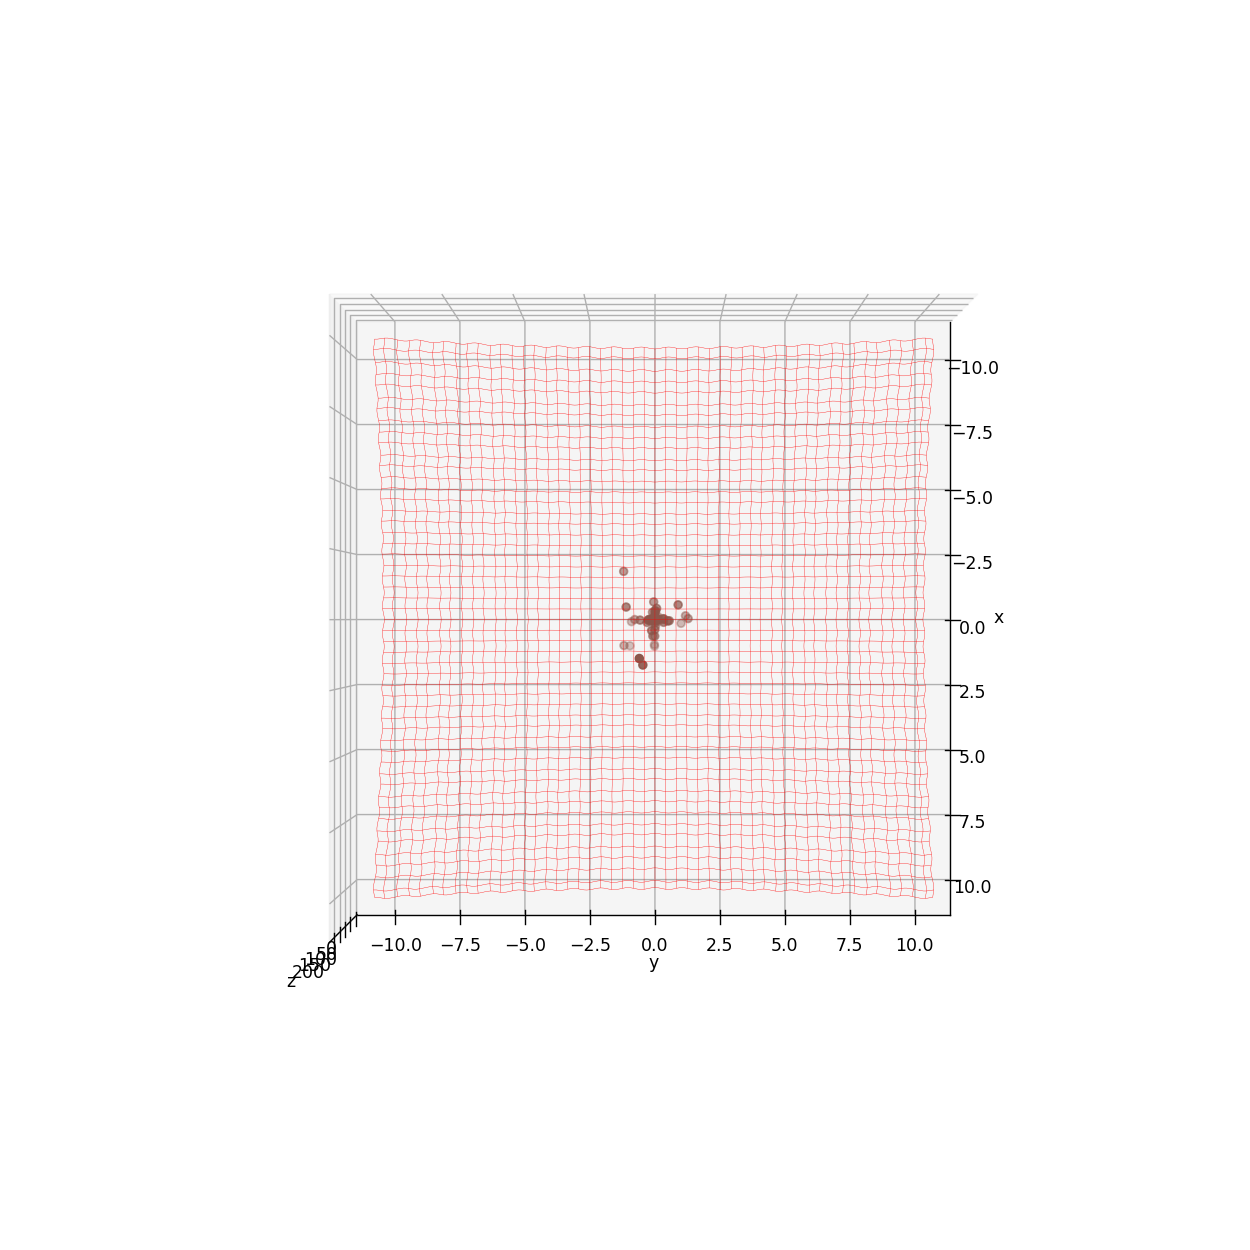

In [131]:
# Plotting prepartion
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
x_data = np.arange(-10, 10, 0.1)
y_data = np.arange(-10, 10, 0.1)
X,Y = np.meshgrid(x_data, y_data)
Z = np.zeros((x_data.size, y_data.size))
for i in range(x_data.size):
    for j in range(y_data.size):
        position = [x_data[i], y_data[j]]
        Z[i,j] = fitness(position)
ax.plot_wireframe(X, Y, Z, color='r', linewidth=0.2)
ax.view_init(azim=0,elev=90)

In [132]:
print("Goal is to minimize rastrigin's function in " + str(dim) + " variables")
print("Function has known min = 0 at (0, 0)", end="")
 
num_particles = 100
max_iter = 100
w = 0.7
aind = 1.5
agrp = 1.5
mode = 0
workerRatio = 0
w_w = 0.5
aind_w = 0.5
agrp_w = 2
dynamic = 0
wmin = 0.1
wmax = 0.9
aindmin = 0.1
aindmax = 3
agrpmin = 0.1
agrpmax = 3

boundx = [-10, 10]
boundy = [-10, 10]
boundary = [boundx, boundy]
    
print("Setting num_particles = " + str(num_particles))
print("Setting max_iter = " + str(max_iter))
print("\nStarting PSO algorithm\n")
 
known_minimum = 0
 
best_position,images,costs = pso(fitness, max_iter, num_particles, dim, w, aind, agrp, boundary, -2, 2, ax, mode, workerRatio, w_w, aind_w, agrp_w, dynamic, wmin, wmax, aindmin, aindmax, agrpmin, agrpmax, known_minimum)
#best_position1,images1,costs1 = pso(fitness, max_iter, num_particles, dim, 0.9, 3, 0.3, boundary, -2, 2, ax, mode, 0.33, w_w, aind_w, agrp_w, dynamic, wmin, wmax, aindmin, aindmax, agrpmin, agrpmax, known_minimum)
#best_position2,images2,costs2 = pso(fitness, max_iter, num_particles, dim, w, aind, agrp, boundary, -2, 2, ax, 1, workerRatio, w_w, aind_w, agrp_w, dynamic, wmin, wmax, aindmin, aindmax, agrpmin, agrpmax, known_minimum)
#best_position3,images3,costs3 = pso(fitness, max_iter, num_particles, dim, w, aind, agrp, boundary, -2, 2, ax, 2, workerRatio, w_w, aind_w, agrp_w, dynamic, wmin, wmax, aindmin, aindmax, agrpmin, agrpmax, known_minimum)
#best_position4,images4,costs4 = pso(fitness, max_iter, num_particles, dim, w, aind, agrp, boundary, -2, 2, ax, mode, workerRatio, w_w, aind_w, agrp_w, 1, wmin, wmax, aindmin, aindmax, agrpmin, agrpmax, known_minimum)

#Generate the animation image and save
animated_image = animation.ArtistAnimation(fig, images)
plt.show()
#animated_image.save('./rastrigin_MW.gif', writer='pillow') 

#x_axis = np.linspace(0, max_iter-1, num = max_iter)
#plt.plot(x_axis, costs, label = 'basic')
#plt.plot(x_axis, costs2, label = 'von Neumann')
#plt.plot(x_axis, costs3, label = 'ring')
#plt.plot(x_axis, costs1, label = 'monarch-worker')
#plt.plot(x_axis, costs4, label = 'dynamic')
#plt.xlabel('iteration')
#plt.ylabel('cost')
#plt.legend()
#plt.savefig('./rastrigin_basic')
 
print("\nPSO completed\n")
print("\nBest solution found:")
print(["%.6f"%best_position[k] for k in range(dim)])
fitnessVal = fitness(best_position)
print("fitness of best solution = %.6f" % fitnessVal)
 
print("\nEnd particle swarm for rastrigin function\n")

Goal is to minimize rastrigin's function in 2 variables
Function has known min = 0 at (0, 0)Setting num_particles = 100
Setting max_iter = 100

Starting PSO algorithm

Iter = 10 best fitness = 0.006
Iter = 20 best fitness = 0.006
Iter = 30 best fitness = 0.000
Iter = 40 best fitness = 0.000
Iter = 50 best fitness = 0.000
Iter = 60 best fitness = 0.000
Iter = 70 best fitness = 0.000
Iter = 80 best fitness = 0.000
Iter = 90 best fitness = 0.000

PSO completed


Best solution found:
['-0.000000', '0.000000']
fitness of best solution = 0.000000

End particle swarm for rastrigin function

